# 전자상거래 배송 지연 분석 — 룰베이스 분류 도출

## 분석 시나리오
한 국제 전자상거래 회사가 전자제품을 판매한다. 최근 배송 지연이 많아져 고객 불만이 쌓이고 있다.
당신은 데이터 분석 담당자로서 **어떤 조건에서 지연이 발생하는지** 찾아내고, 단순한 룰만으로 지연 가능성을 예측할 수 있는지 확인해야 한다.

## 분석 흐름
1. **데이터 파악**  — 컬럼, 타입, 분포 확인
2. **시각화 탐색**  — 단변량/타겟별 분포 비교
3. **인사이트 정리**  — 강한 시그널 vs 약한 시그널
4. **룰 도출 및 검증**  — 룰1, 룰2 정의 후 정확도/혼동행렬 확인
5. **잔여 영역 심화 분석**  — 잔여 영역에서 룰3 발견 + 3개 룰 종합 평가

## 데이터
- 파일: `배송데이터_전체.csv` (10,999행, 11개 컬럼)
- 타겟: `배송결과` (`지연` / `정시`)

---

## 0. 환경 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지 (환경에 설치된 첫 번째 한글 폰트 사용)
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
pd.set_option('display.max_columns', None)

---
## 1. 데이터 파악

### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.

In [ ]:
df = pd.read_csv('배송데이터_전체.csv')
print('데이터 모양:', df.shape)
df.head()

데이터 모양: (10999, 11)


,창고블록,배송수단,문의전화수,고객평점,상품가격,이전구매횟수,상품중요도,성별,할인율,무게_그램,배송결과
0,D,항공,4,2,177,3,하,여,44,1233,지연
1,F,항공,4,5,216,2,하,남,59,3088,지연
2,A,항공,2,2,183,4,하,남,48,3374,지연
3,B,항공,3,3,176,4,중,남,10,1177,지연
4,C,항공,2,2,184,3,중,여,46,2484,지연


**해석:** 10,999행 × 11개 컬럼. 각 행은 한 건의 배송 주문을 의미한다.

### 과제 1-2. 각 컬럼의 데이터 타입과 결측치를 확인하시오.

In [ ]:
print(df.info())
print('\n결측치 개수:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   창고블록    10999 non-null  object
 1   배송수단    10999 non-null  object
 2   문의전화수   10999 non-null  int64 
 3   고객평점    10999 non-null  int64 
 4   상품가격    10999 non-null  int64 
 5   이전구매횟수  10999 non-null  int64 
 6   상품중요도   10999 non-null  object
 7   성별      10999 non-null  object
 8   할인율     10999 non-null  int64 
 9   무게_그램   10999 non-null  int64 
 10  배송결과    10999 non-null  object
dtypes: int64(6), object(5)
memory usage: 945.4+ KB
None

결측치 개수:
창고블록      0
배송수단      0
문의전화수     0
고객평점      0
상품가격      0
이전구매횟수    0
상품중요도     0
성별        0
할인율       0
무게_그램     0
배송결과      0
dtype: int64


**해석:** 결측치는 없다. 수치형 6개와 범주형 4개, 그리고 타겟(`배송결과`)으로 구성됨.

### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.

In [ ]:
df.describe()

,문의전화수,고객평점,상품가격,이전구매횟수,할인율,무게_그램
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729
std,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000
25%,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000


**해석:** 무게는 1,001g ~ 7,846g, 할인율은 1 ~ 65% 범위. 할인율의 75% 분위수가 10인 점이 눈에 띈다 — 즉 대부분의 상품은 할인이 10% 이하라는 뜻. 큰 할인이 걸린 상품은 소수다.

### 과제 1-4. 타겟 변수 `배송결과`의 분포를 확인하시오. 클래스 불균형이 있는지 평가하시오.

배송결과
지연    6563
정시    4436
Name: count, dtype: int64

비율:
배송결과
지연    0.597
정시    0.403
Name: proportion, dtype: float64


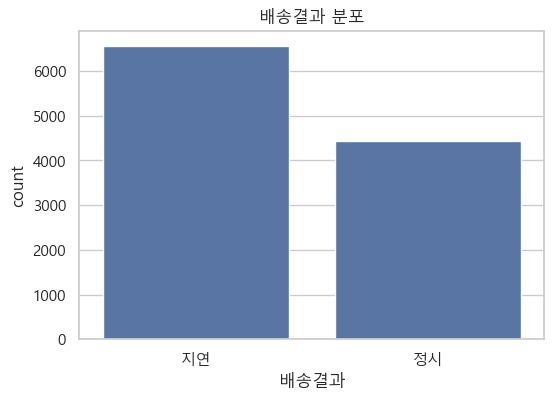

In [ ]:
print(df['배송결과'].value_counts())
print('\n비율:')
print(df['배송결과'].value_counts(normalize=True).round(3))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='배송결과')
plt.title('배송결과 분포')
plt.show()

**해석:** 지연 59.7%, 정시 40.3%. 지연 비율이 더 높은 약한 불균형 상태. 베이스라인(아무 룰도 없이 모두 지연으로 예측)의 정확도가 약 60%라는 의미 — 우리가 만들 룰은 이보다 높아야 의미 있다.

### 과제 1-5. 범주형 변수의 카테고리별 빈도를 확인하시오.

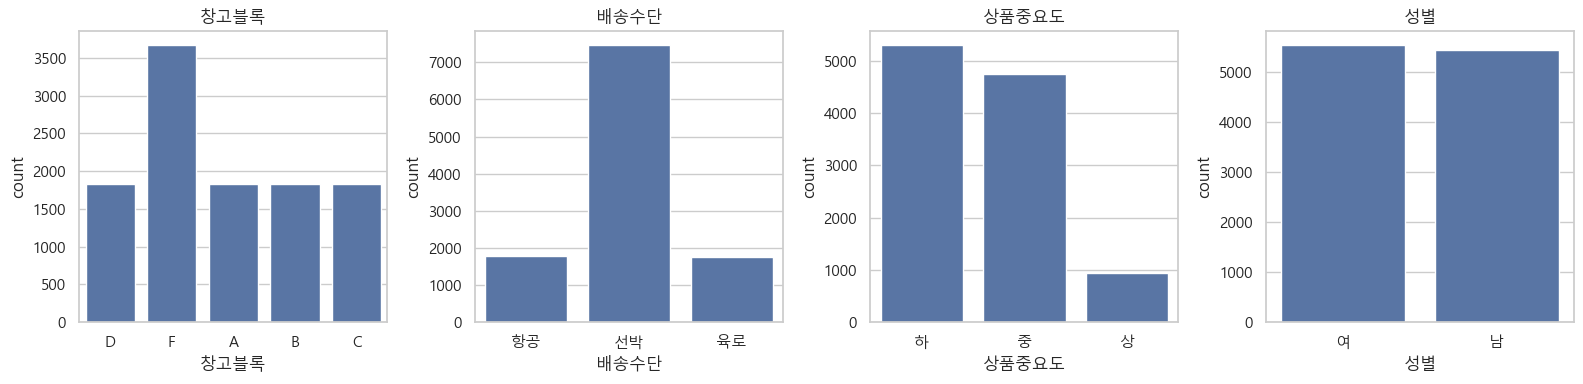

In [ ]:
cat_cols = ['창고블록', '배송수단', '상품중요도', '성별']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

**해석:** 창고블록 F가 다른 블록의 약 2배 비중. 배송수단은 선박이 압도적(약 68%). 상품중요도는 하/중이 대부분이고 상은 소수. 성별은 거의 균등.

---
## 2. 시각화 탐색

이제 각 피처가 `배송결과`와 어떤 관계가 있는지 살펴본다. 강한 관계가 있는 피처는 룰의 후보가 된다.

### 과제 2-1. 수치형 변수들의 분포(히스토그램)를 한눈에 보시오.

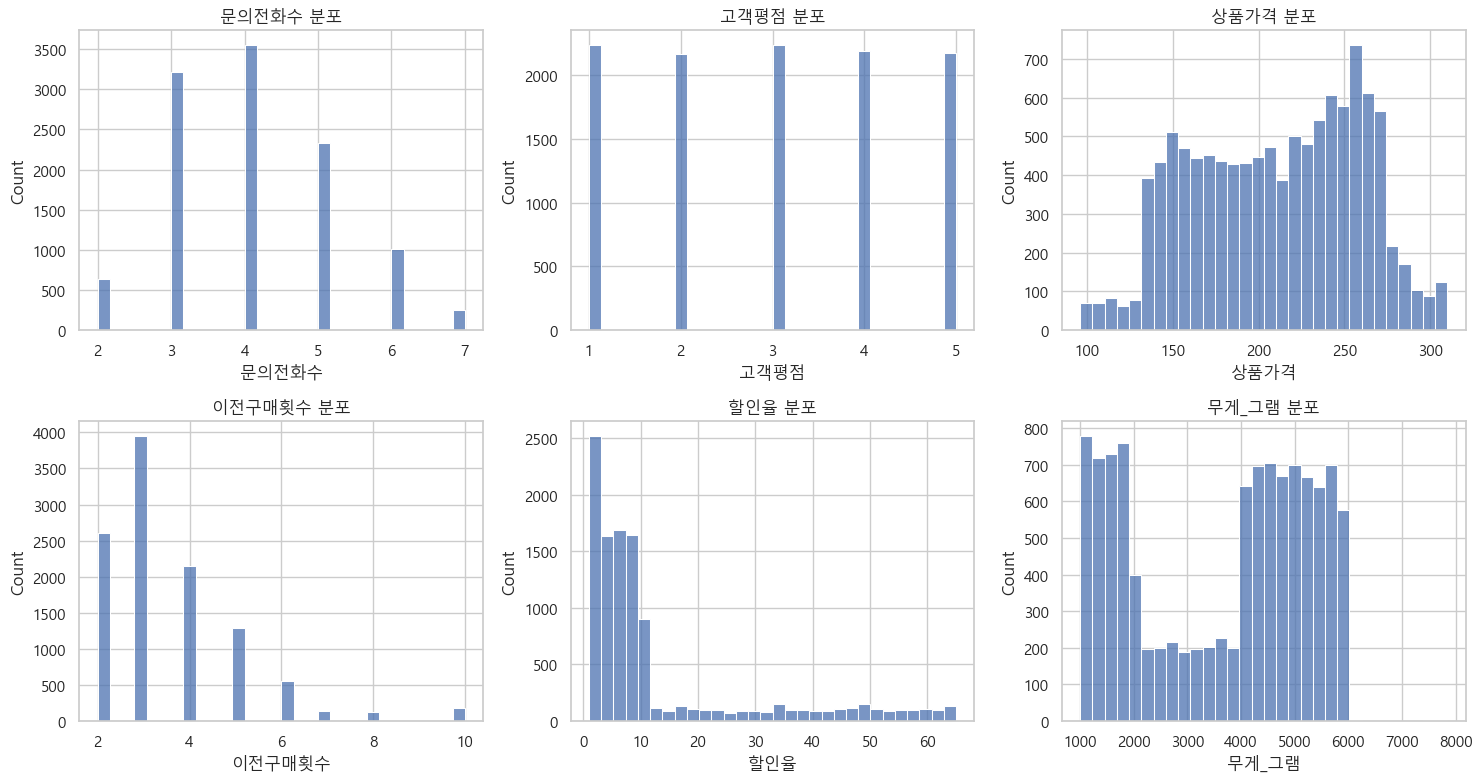

In [ ]:
num_cols = ['문의전화수', '고객평점', '상품가격', '이전구매횟수', '할인율', '무게_그램']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, bins=30, ax=ax)
    ax.set_title(f'{col} 분포')
plt.tight_layout()
plt.show()

**해석:** 두 가지 흥미로운 분포가 보인다.
- **할인율:** 대부분 1~10에 몰려 있고 그 이후로 길게 꼬리가 늘어진 형태. 10을 경계로 데이터 성격이 다를 가능성.
- **무게_그램:** 봉우리가 두 개(약 1,500g, 약 5,000g) 보이는 **이봉분포**. 중간 영역(2,000~4,000g)이 비어 있음.

이 두 변수는 추가 탐색이 필요하다.

### 과제 2-2. 수치형 변수 각각에 대해 `배송결과`별 박스플롯을 그려 비교하시오.

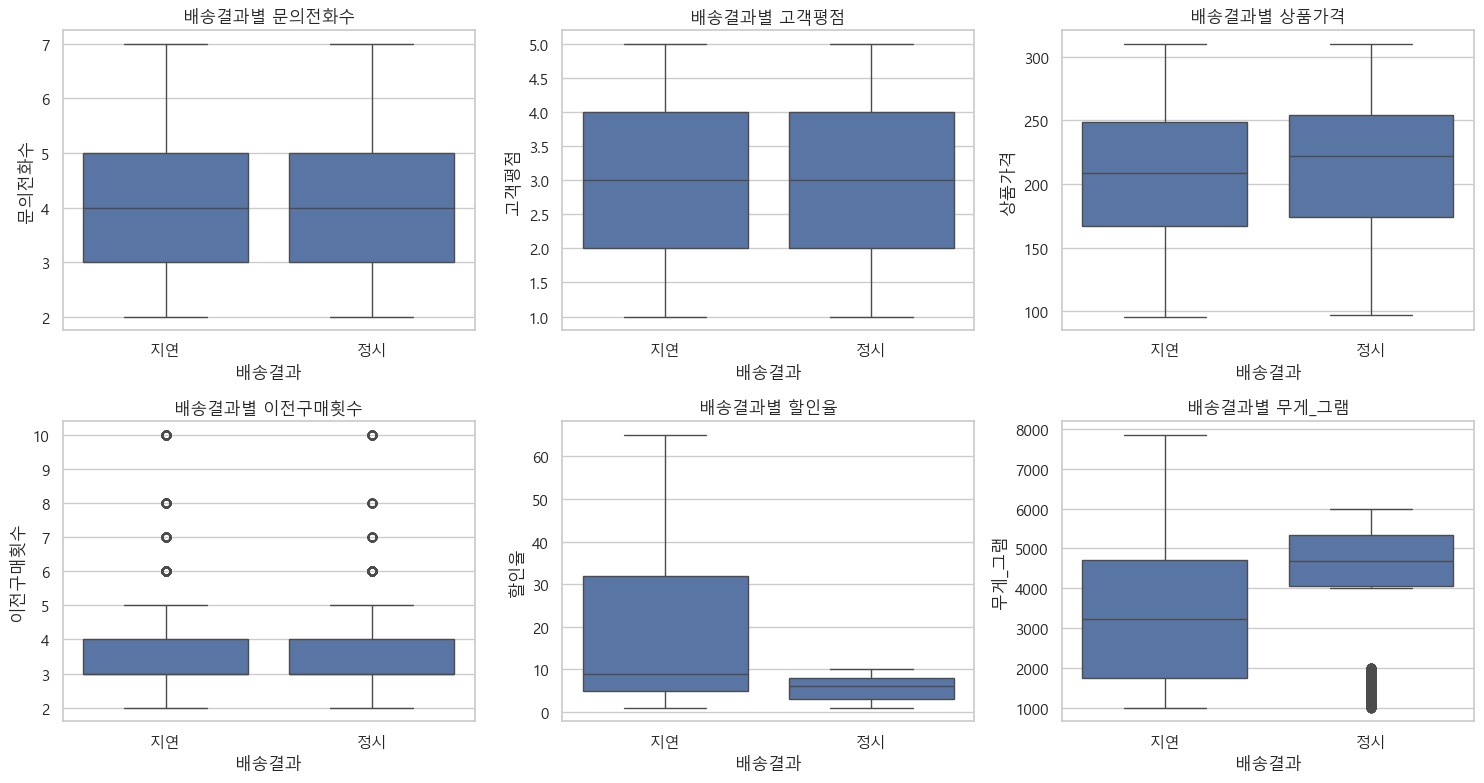

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x='배송결과', y=col, ax=ax)
    ax.set_title(f'배송결과별 {col}')
plt.tight_layout()
plt.show()

**해석:** 박스플롯에서 두 그룹이 명확히 갈리는 변수는 다음과 같다.
- **할인율:** 지연 그룹의 중앙값과 상위 75%가 정시 그룹보다 훨씬 큼. 큰 할인이 걸린 상품일수록 지연.
- **무게_그램:** 두 그룹의 분포 형태 자체가 다름.

반대로 **고객평점, 상품가격, 이전구매횟수**는 두 그룹이 거의 겹쳐 — 약한 시그널이거나 무관할 가능성.

### 과제 2-3. 범주형 변수 각각에 대해 `배송결과`별 빈도를 비교하시오.

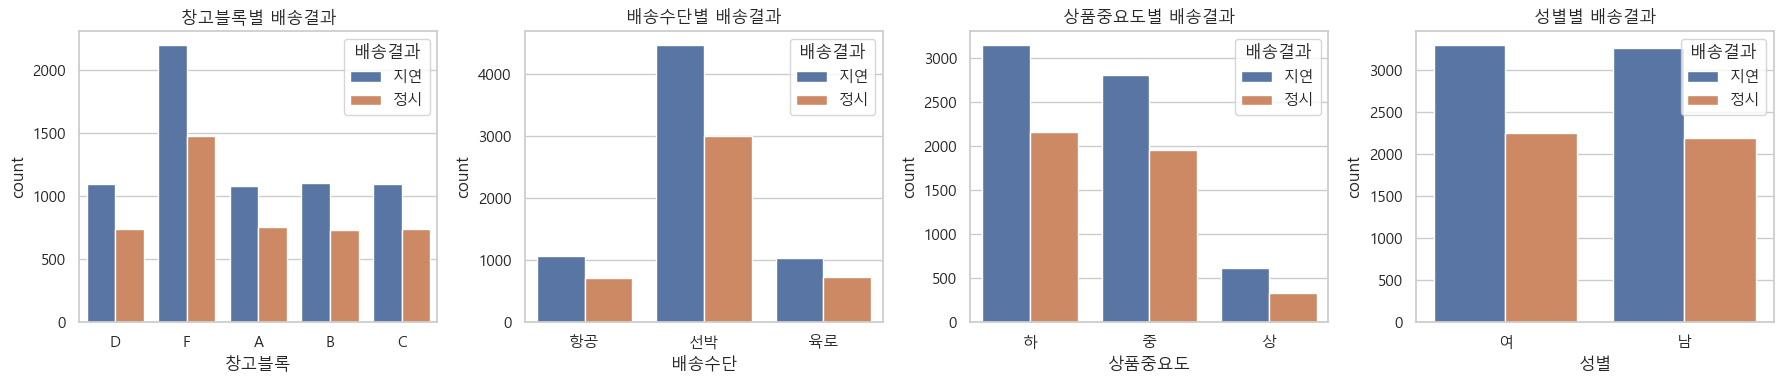

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='배송결과', ax=ax)
    ax.set_title(f'{col}별 배송결과')
plt.tight_layout()
plt.show()

**해석:** 모든 범주형 변수에서 카테고리별 지연/정시 비율이 거의 비슷하게 유지된다. 즉 **창고블록, 배송수단, 상품중요도, 성별은 배송결과를 거의 설명하지 못한다.** 룰 후보에서 제외할 수 있다.

### 과제 2-4. 핵심 변수로 보이는 `할인율`을 자세히 들여다보시오. 할인율 구간별(5%단위 구간) 지연 비율을 표와 그래프로 확인.

,할인율_구간,지연비율,건수
0,0~5,0.474140,4157
1,5~10,0.463647,4195
2,10~20,1.000000,496
3,20~30,1.000000,441
4,30+,1.000000,1710


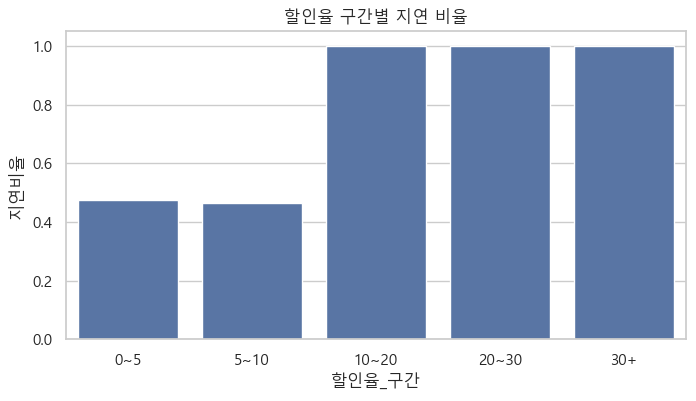

In [ ]:
df['할인율_구간'] = pd.cut(df['할인율'],
                          bins=[0, 5, 10, 20, 30, 70],
                          labels=['0~5', '5~10', '10~20', '20~30', '30+'],
                          include_lowest=True)
disc_table = df.groupby('할인율_구간', observed=True)['배송결과'].apply(
    lambda s: (s == '지연').mean()
).reset_index(name='지연비율')

# 그룹바이 디버깅 코드
# for n, g in df.groupby('할인율_구간', observed=True)['배송결과']:
#     print(n)
#     print( (g=='지연').mean() )

disc_table['건수'] = df['할인율_구간'].value_counts().sort_index().values
display(disc_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=disc_table, x='할인율_구간', y='지연비율')
plt.title('할인율 구간별 지연 비율')
plt.ylim(0, 1.05)
plt.show()

**해석 — 첫 번째 핵심 발견.**
- 할인율 **10 이하**: 지연 비율이 약 47%로 평균 이하
- 할인율 **10 초과**: **100% 지연** (예외 0건!)

이건 단순한 상관관계가 아니라 **결정적 규칙**이다. 할인율이 10을 넘는 순간 지연이 확정된다. **룰 1번 후보**가 도출되었다.

### 과제 2-5. 또 다른 핵심 변수인 `무게_그램`을 자세히 들여다보시오. 무게 구간별 지연 비율을 확인.

,무게_구간,지연비율,건수
0,1~2kg,0.677658,3245
1,2~3kg,1.000000,899
2,3~4kg,0.998875,889
3,4~5kg,0.436789,3077
4,5~6kg,0.425200,2881
5,6kg+,1.000000,8


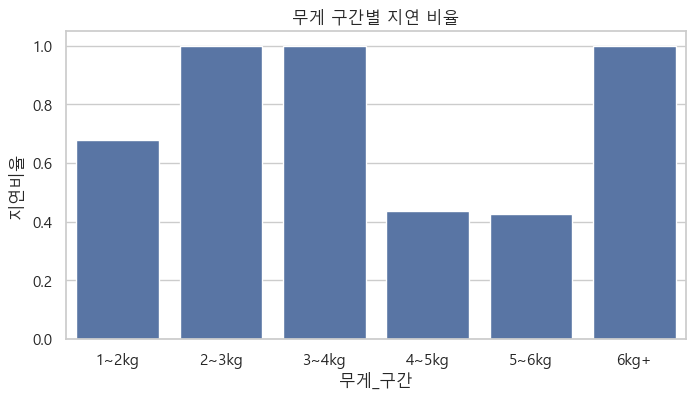

In [ ]:
df['무게_구간'] = pd.cut(df['무게_그램'],
                       bins=[1000, 2000, 3000, 4000, 5000, 6000, 8000],
                       labels=['1~2kg', '2~3kg', '3~4kg', '4~5kg', '5~6kg', '6kg+'])
weight_table = df.groupby('무게_구간', observed=True)['배송결과'].apply(
    lambda s: (s == '지연').mean()
).reset_index(name='지연비율')
weight_table['건수'] = df['무게_구간'].value_counts().sort_index().values
display(weight_table)

plt.figure(figsize=(8, 4))
sns.barplot(data=weight_table, x='무게_구간', y='지연비율')
plt.title('무게 구간별 지연 비율')
plt.ylim(0, 1.05)
plt.show()

**해석 — 두 번째 핵심 발견.**
- 무게 **2~3kg**: 지연 100%
- 무게 **3~4kg**: 지연 99.9% (거의 100%)
- 무게 **4 ~ 5kg, 5 ~ 6kg**: 지연 약 43% (오히려 정시가 더 많음)
- 무게 **1~2kg**: 지연 약 68%

즉 **무게 2 ~ 4kg 구간이 지연의 결정적 구간**이다. 이 구간을 벗어나면 지연 가능성이 급격히 떨어진다. **룰 2번 후보**가 도출되었다.

### 과제 2-6. 두 핵심 변수(할인율, 무게)를 동시에 보는 산점도를 그려, 결과별로 색을 다르게 해 패턴을 확인하시오.

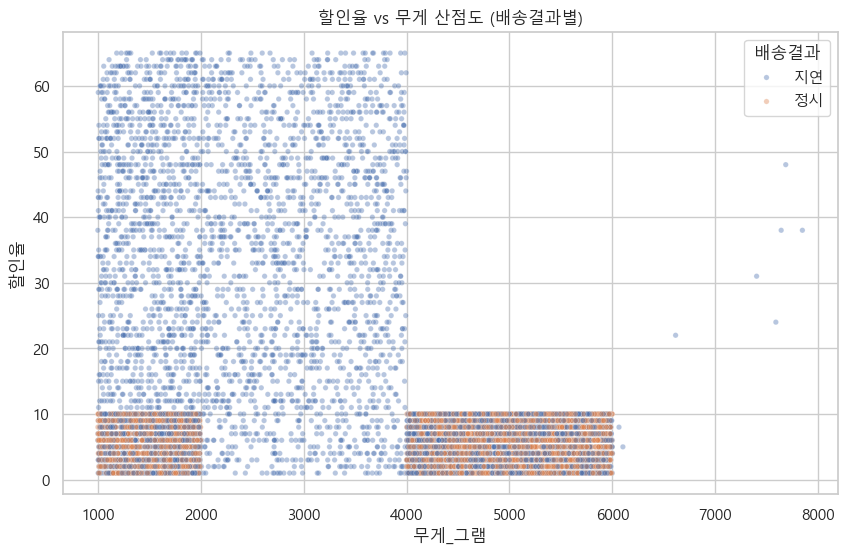

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='무게_그램', y='할인율', hue='배송결과', alpha=0.4, s=15)
plt.title('할인율 vs 무게 산점도 (배송결과별)')
plt.show()

**해석:** 색으로 구분해보면 두 룰의 영역이 시각적으로 드러난다.
- 할인율이 약 10을 넘는 위쪽 영역은 거의 모두 지연 색으로 채워짐
- 무게 2~4kg 사이의 세로 띠 영역도 거의 지연 색으로 채워짐

다만 **두 룰의 영역을 모두 벗어난 좌하단(무게<2kg, 할인율≤10)과 우하단(무게>4kg, 할인율≤10)은 정시와 지연이 섞여있다.** 이 영역은 두 룰만으로는 분류가 안 되는 부분이며, 나중에 다시 들여다볼 가치가 있다.

### 과제 2-7. 수치형 변수들 간의 상관관계를 히트맵으로 확인하시오. (`배송결과`도 0/1로 변환해 포함)

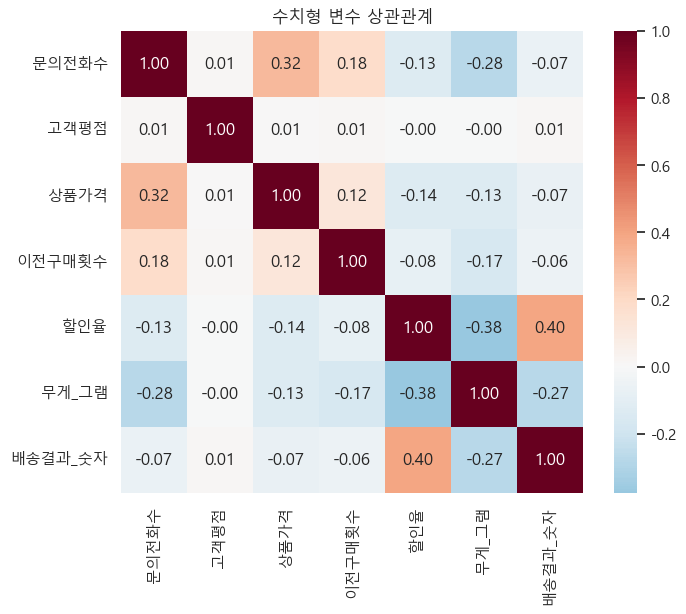

In [ ]:
df_corr = df.copy()
df_corr['배송결과_숫자'] = (df_corr['배송결과'] == '지연').astype(int)
corr = df_corr[num_cols + ['배송결과_숫자']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('수치형 변수 상관관계')
plt.show()

**해석:** `배송결과_숫자`와의 상관관계를 보면 **할인율(+0.40)** 이 가장 강하다. 무게는 -0.27로 음의 상관이지만, 앞서 봤듯이 **선형 관계가 아니라 구간적 관계**(2~4kg에서 100%, 그 외에서는 다름)임에 주의. 상관계수 하나만 보면 무게의 진짜 효과를 놓친다.

---
## 3. 인사이트 정리

### 과제 3-1. 지금까지의 탐색 결과를 표로 정리하시오. 어떤 피처가 강한 시그널이고 어떤 피처가 약한지 평가.

In [ ]:
insight = pd.DataFrame({
    '피처': ['할인율', '무게_그램', '문의전화수', '이전구매횟수',
            '상품가격', '고객평점', '상품중요도', '배송수단', '창고블록', '성별'],
    '시그널 강도': ['매우 강함', '매우 강함', '약함', '약함',
                  '없음', '없음', '없음', '없음', '없음', '없음'],
    '관계 형태': ['임계값(10)', '구간(2~4kg)', '약한 음의 상관', '약한 패턴',
                '거의 무관', '거의 무관', '거의 무관', '거의 무관', '거의 무관', '거의 무관'],
    '룰 후보': ['예 ✓', '예 ✓', '아니오', '아니오',
              '아니오', '아니오', '아니오', '아니오', '아니오', '아니오']
})
display(insight)

,피처,시그널 강도,관계 형태,룰 후보
0,할인율,매우 강함,임계값(10),예 ✓
1,무게_그램,매우 강함,구간(2~4kg),예 ✓
2,문의전화수,약함,약한 음의 상관,아니오
3,이전구매횟수,약함,약한 패턴,아니오
4,상품가격,없음,거의 무관,아니오
5,고객평점,없음,거의 무관,아니오
6,상품중요도,없음,거의 무관,아니오
7,배송수단,없음,거의 무관,아니오
8,창고블록,없음,거의 무관,아니오
9,성별,없음,거의 무관,아니오


**해석:** 두 피처가 명확히 두드러진다.
1. **할인율**이 10을 넘으면 100% 지연 (임계값 룰)
2. **무게**가 2~4kg 사이면 거의 100% 지연 (구간 룰)

나머지 피처들은 단변량 차원에서는 룰베이스 분류에 거의 기여하지 못한다. 다만 산점도에서 본 "섞인 영역"에서는 다른 시그널이 숨어있을 수도 있으므로 5장에서 다시 확인할 것이다.

---
## 4. 룰 도출 및 검증

### 과제 4-1. 위 인사이트를 바탕으로 두 가지 룰을 정의하고, 각각의 정확도를 베이스라인(항상 지연으로 예측하는 모델)과 비교하시오.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

actual = (df['배송결과'] == '지연').astype(int)

# 베이스라인: 항상 지연으로 예측
baseline = np.ones(len(df), dtype=int)
acc_baseline = accuracy_score(actual, baseline)

# 룰 1: 할인율 > 10 → 지연
rule1 = (df['할인율'] > 10).astype(int)
acc_rule1 = accuracy_score(actual, rule1)

# 룰 2: 무게 2000~4000g → 지연
rule2 = df['무게_그램'].between(2000, 4000).astype(int)
acc_rule2 = accuracy_score(actual, rule2)

print(f'베이스라인(항상 지연):       정확도 {acc_baseline:.3f}')
print(f'룰1 (할인율>10 → 지연):      정확도 {acc_rule1:.3f}')
print(f'룰2 (무게 2~4kg → 지연):     정확도 {acc_rule2:.3f}')

베이스라인(항상 지연):       정확도 0.597
룰1 (할인율>10 → 지연):      정확도 0.644
룰2 (무게 2~4kg → 지연):     정확도 0.566


**해석:** 룰1 단독으로 이미 베이스라인보다 4.7%p 높은 64.4%. 룰2는 단독으로는 베이스라인보다 낮은데, 이는 룰2가 적용되는 구간(2~4kg) 자체가 전체의 약 16%에 불과하기 때문. **두 룰은 서로 다른 영역을 잡으므로 결합해야 진가가 나온다.**

### 과제 4-2. 두 룰을 OR 조건으로 결합하여 최종 룰을 만들고, 정확도와 혼동행렬, 정밀도/재현율을 확인하시오.

결합 룰 정확도: 0.668
베이스라인 대비 향상: +7.1%p

혼동행렬:


,예측 정시,예측 지연
실제 정시,4433,3
실제 지연,3647,2916



분류 리포트:
              precision    recall  f1-score   support

          정시       0.55      1.00      0.71      4436
          지연       1.00      0.44      0.62      6563

    accuracy                           0.67     10999
   macro avg       0.77      0.72      0.66     10999
weighted avg       0.82      0.67      0.65     10999



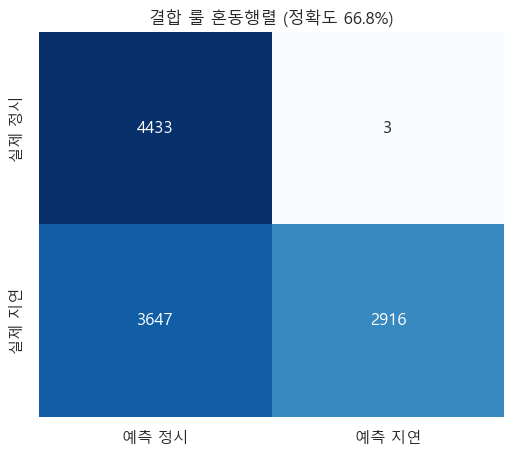

In [ ]:
# 결합 룰: 룰1 OR 룰2
combined = ((df['할인율'] > 10) | (df['무게_그램'].between(2000, 4000))).astype(int)
acc_combined = accuracy_score(actual, combined)

print(f'결합 룰 정확도: {acc_combined:.3f}')
print(f'베이스라인 대비 향상: +{(acc_combined - acc_baseline)*100:.1f}%p')

cm = confusion_matrix(actual, combined)
cm_df = pd.DataFrame(cm,
                     index=['실제 정시', '실제 지연'],
                     columns=['예측 정시', '예측 지연'])
print('\n혼동행렬:')
display(cm_df)

print('\n분류 리포트:')
print(classification_report(actual, combined, target_names=['정시', '지연']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'결합 룰 혼동행렬 (정확도 {acc_combined:.1%})')
plt.show()

**해석:**
- 전체 정확도 **66.8%** (베이스라인 대비 +7.1%p)
- 지연 예측 정밀도 **99.9%** — 룰이 "지연"이라고 한 2,919건 중 실제 지연이 2,916건
- 지연 재현율 **44.4%** — 실제 지연 6,563건 중 절반 이상(3,647건)을 놓침

룰베이스의 한계가 recall에서 드러난다. 산점도에서 본 잔여 영역에서 추가 시그널이 있는지 5장에서 확인한다.

---
## 5. 잔여 영역 심화 분석

### 배경
룰1 + 룰2는 지연 recall 0.444에 불과하다. 산점도에서 두 룰이 못 잡는 영역에 정시와 지연이 섞여 있었다. 그 영역을 다시 들여다보면 추가 룰이 나올지 확인한다.

### 과제 5-1. 룰1, 룰2 둘 다 적용되지 않는 "잔여 영역"의 데이터를 추출하고 그 크기와 지연율을 확인하시오.

In [ ]:
mask_residual = (df['할인율'] <= 10) & ~(df['무게_그램'].between(2000, 4000))
residual = df[mask_residual]

print(f'잔여 영역 크기: {len(residual):,}건 (전체의 {len(residual)/len(df)*100:.1f}%)')
print(f'잔여 영역 지연율: {(residual["배송결과"]=="지연").mean():.3f}')
print(f'\n잔여 영역 배송결과 분포:')
print(residual['배송결과'].value_counts())

잔여 영역 크기: 8,080건 (전체의 73.5%)
잔여 영역 지연율: 0.451

잔여 영역 배송결과 분포:
배송결과
정시    4433
지연    3647
Name: count, dtype: int64


**해석:** 잔여 영역은 8,080건으로 전체의 73.5%나 차지한다. 지연율 45.1%로 정시/지연이 거의 반반 — 룰을 찾기 어려워 보이지만, 영역을 더 쪼개면 다를 수 있다.

### 과제 5-2. 잔여 영역을 무게 기준으로 두 부분으로 분해하고 각각의 지연율을 비교하시오.
- 영역 A: 무게 < 2kg AND 할인율 ≤ 10
- 영역 B: 무게 > 4kg

In [ ]:
mask_A = (df['무게_그램'] < 2000) & (df['할인율'] <= 10)
mask_B = df['무게_그램'] > 4000
A = df[mask_A]
B = df[mask_B]

print(f'영역 A (무게<2kg & 할인율<=10): {len(A):,}건, 지연율 {(A["배송결과"]=="지연").mean():.3f}')
print(f'영역 B (무게>4kg):              {len(B):,}건, 지연율 {(B["배송결과"]=="지연").mean():.3f}')

영역 A (무게<2kg & 할인율<=10): 2,120건, 지연율 0.508
영역 B (무게>4kg):              5,966건, 지연율 0.432


**해석:** 영역 A의 지연율(50.8%)이 영역 B(43.2%)보다 약간 높다. 두 영역은 성격이 다를 가능성이 있어 각각 따로 분석한다.

### 과제 5-3. 영역 A에서 각 변수별 지연 비율을 막대그래프로 비교하여 시그널이 있는 변수를 찾으시오.
- 변수: ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

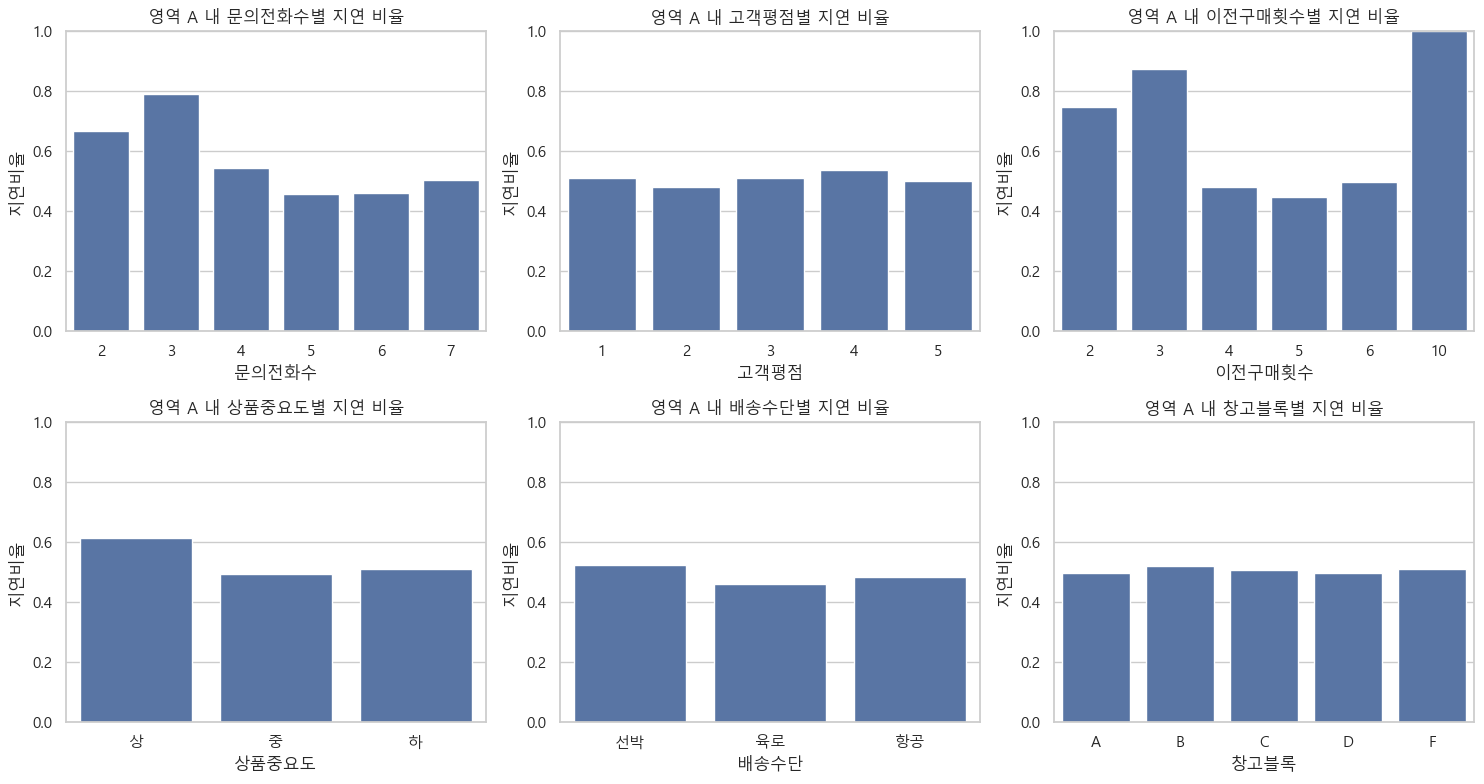

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']):
    grp = A.groupby(col, observed=True)['배송결과'].apply(
        lambda s: (s == '지연').mean()).reset_index(name='지연비율')
    sns.barplot(data=grp, x=col, y='지연비율', ax=ax)
    ax.set_title(f'영역 A 내 {col}별 지연 비율')
    ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

**해석:** 영역 A에서는 **이전구매횟수**가 가장 강한 시그널을 보인다. 이전구매횟수 2 ~ 3회에서 지연율이 70 ~ 90%까지 치솟고, 4회 이상에서는 평균 수준(45 ~ 50%)으로 떨어진다. 문의전화수도 약한 시그널을 보이지만 이전구매횟수만큼 명확하지 않다.

### 과제 5-4. 영역 A 내 이전구매횟수별 지연 비율을 정확히 표로 확인하시오.

In [ ]:
prior_table = A.groupby('이전구매횟수')['배송결과'].apply(
    lambda s: (s == '지연').mean()).round(3).reset_index(name='지연비율')
prior_table['건수'] = A['이전구매횟수'].value_counts().sort_index().values
display(prior_table)

,이전구매횟수,지연비율,건수
0,2,0.747,95
1,3,0.874,135
2,4,0.482,869
3,5,0.447,810
4,6,0.498,209
5,10,1.000,2


**해석:** 이전구매횟수 2회는 지연율 74.7%, 3회는 87.4%로 매우 강하다. 4회부터는 48% 수준으로 평균에 수렴한다. **임계값은 3회**가 적절해 보인다 — "이전구매횟수 ≤ 3"이라는 단순 조건으로 영역 A 내에서 강한 분류가 가능하다.

### 과제 5-5. 영역 B에서도 같은 방법으로 변수별 지연 비율을 확인하시오.

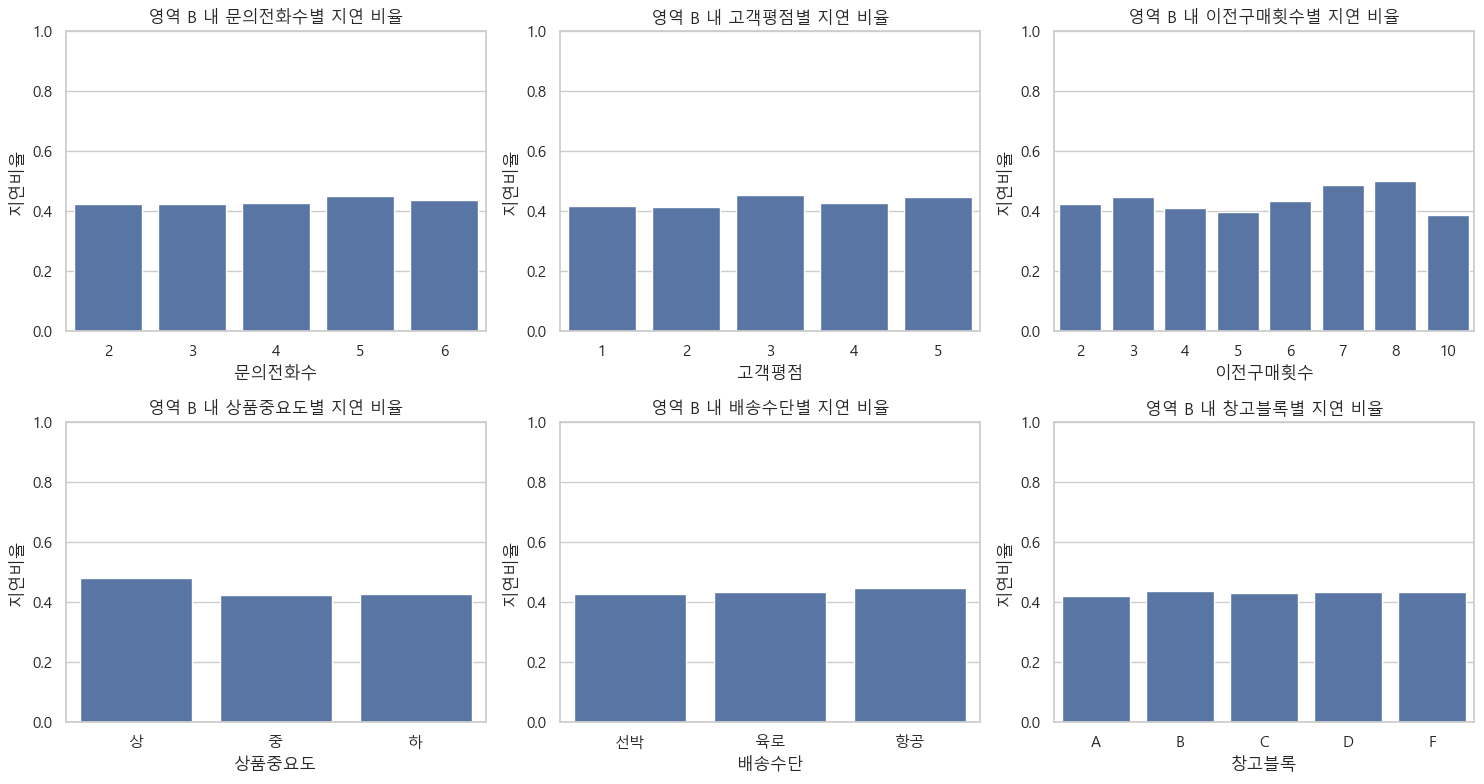

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']):
    grp = B.groupby(col, observed=True)['배송결과'].apply(
        lambda s: (s == '지연').mean()).reset_index(name='지연비율')
    sns.barplot(data=grp, x=col, y='지연비율', ax=ax)
    ax.set_title(f'영역 B 내 {col}별 지연 비율')
    ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

**해석:** 영역 B(무게 > 4kg)에서는 **모든 변수가 평탄**하다. 어떤 변수로 그룹을 나눠도 지연율이 41~46% 사이에 머문다. 영역 A에서 강한 시그널이었던 이전구매횟수도 영역 B에서는 사라진다.

**중요한 인사이트:** 같은 변수(이전구매횟수)가 가벼운 상품에서는 강한 시그널이지만 무거운 상품에서는 무관하다. 즉 **고객 특성보다는 물류 자체의 한계로 보이는 영역**이 영역 B다. 룰베이스로는 더 이상 분류할 수 없으며, 여기는 ML 모델이 필요한 영역이다.

### 과제 5-6. 영역 A에서 발견한 시그널을 바탕으로 룰3을 정의하고, 기존 두 룰과 결합한 최종 성능을 평가하시오.

**룰3: 무게 < 2kg AND 할인율 ≤ 10 AND 이전구매횟수 ≤ 3 → 지연**

In [ ]:
# 세 룰 정의
r1 = (df['할인율'] > 10)
r2 = df['무게_그램'].between(2000, 4000)
r3 = (df['무게_그램'] < 2000) & (df['할인율'] <= 10) & (df['이전구매횟수'] <= 3)

# 시나리오별 성능 비교
scenarios = [
    ('베이스라인 (모두 지연)', np.ones(len(df), dtype=int)),
    ('룰1 + 룰2', (r1 | r2).astype(int)),
    ('룰1 + 룰2 + 룰3', (r1 | r2 | r3).astype(int)),
]

rows = []
for name, pred in scenarios:
    n_pred = pred.sum()
    tp = ((pred == 1) & (actual == 1)).sum()
    fn = ((pred == 0) & (actual == 1)).sum()
    recall = tp / actual.sum()
    precision = tp / n_pred if n_pred > 0 else 0
    accuracy = accuracy_score(actual, pred)
    rows.append({
        '시나리오': name,
        '지연 예측': n_pred,
        'TP': tp,
        'FN(놓침)': fn,
        '지연 recall': round(recall, 3),
        '지연 precision': round(precision, 3),
        '정확도': round(accuracy, 3),
    })

result = pd.DataFrame(rows)
display(result)

,시나리오,지연 예측,TP,FN(놓침),지연 recall,지연 precision,정확도
0,베이스라인 (모두 지연),10999,6563,0,1.000,0.597,0.597
1,룰1 + 룰2,2919,2916,3647,0.444,0.999,0.668
2,룰1 + 룰2 + 룰3,3149,3105,3458,0.473,0.986,0.682


**해석:** 룰3 추가의 효과 정리:
- 지연 recall: **0.444 → 0.473 (+2.9%p)** — 새로 189건의 지연을 추가로 잡음
- 지연 precision: 0.999 → 0.986 — 거의 유지(false positive 41건만 발생)
- 정확도: 0.668 → 0.682 (+1.4%p)

룰베이스의 한계도 함께 드러난다. 정확도 68%는 베이스라인 60%보다 낫지만, 지연 recall은 47%에 불과 — **실제 지연의 절반 이상은 여전히 룰로 못 잡는다.** 이 한계는 영역 B 같은 "시그널이 평탄한 영역"에서 발생하며, 여기서부터는 ML 모델의 영역이다.

---
## 6. 분석 자체 점검

### 점검 항목

1. **다양한 탐색이 이루어졌는가?**
   - 데이터 파악(1-1 ~ 1-5), 시각화(2-1 ~ 2-7), 인사이트(3-1), 룰 검증(4-1 ~ 4-2), 잔여 영역 심화(5-1 ~ 5-6)
   - **총 21개의 분석 과제** ✓

2. **룰 2개 이상이 자연스럽게 도출되는가?**
   - 룰1 (할인율 > 10): 과제 2-4 단변량 구간 분석에서 발견
   - 룰2 (무게 2~4kg): 과제 2-5 단변량 구간 분석에서 발견
   - 룰3 (무게<2kg & 할인율≤10 & 이전구매≤3): 과제 5-3, 5-4 잔여 영역 분해 후 발견
   - **세 룰 모두 시각화에서 직접 도출됨** ✓

3. **탐색이 룰과 자연스럽게 연결되는가?**
   - 단변량 분포(2-1) → 박스플롯(2-2) → 구간 분석(2-4, 2-5) → 룰1, 룰2 도출
   - 산점도(2-6) → 잔여 영역 시각적 식별
   - 잔여 영역 추출(5-1) → 무게 기준 분해(5-2) → 영역 A 변수 분석(5-3, 5-4) → 룰3 도출
   - 영역 B 분석(5-5)에서 시그널 부재 → 룰베이스 한계 → ML 필요성 도출
   - 3개 룰 결합 성능 비교(5-6)에서 recall 향상 확인 ✓

4. **시각화 일관성**
   - 모든 그래프 seaborn 기반(countplot, histplot, boxplot, barplot, scatterplot, heatmap)
   - 산점도와 막대그래프에 오버레이 없는 단순 형태 ✓

5. **시간 분량**
   - 데이터 파악 5분 + 시각화 15분 + 인사이트 5분 + 룰 검증 5분 + 잔여 영역 심화 10분 ≈ **약 40분**

### 결론
세 룰이 단계적 깊이로 도출되는 흐름이 완성되었다. 룰1, 2는 단변량으로 명확히 보이는 강한 시그널이고, 룰3은 잔여 영역을 분해해야만 보이는 약한 시그널이다. 영역 B에서 추가 룰을 못 찾은 것 자체가 룰베이스의 한계를 드러내어 ML 모델 학습 단계로 자연스럽게 연결된다.